# **How are in-demand skills trending for Data Analysts?**

### Methodology
1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

In [100]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [90]:
df_DA_DE = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'Germany')].copy()

df_DA_DE['job_posted_month_no'] = df_DA_DE['job_posted_date'].dt.month

df_DA_DE_exploded = df_DA_DE.explode('job_skills')

In [91]:
df_DA_DE_pivot = df_DA_DE_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_DE_pivot.loc['Total'] = df_DA_DE_pivot.sum()

df_DA_DE_pivot  = df_DA_DE_pivot[df_DA_DE_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_DE_pivot = df_DA_DE_pivot.drop('Total')

In [92]:
df_DA_DE_pivot

job_skills,sql,python,excel,tableau,power bi,r,sap,powerpoint,sas,vba,...,keras,kotlin,splunk,microsoft teams,neo4j,openstack,phoenix,scikit-learn,pytorch,notion
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,14,9,14,14,8,5,5,3,6,3,...,0,1,0,0,0,0,0,0,0,0
2,16,15,12,9,8,5,3,3,4,0,...,0,0,0,0,0,1,0,0,0,0
3,9,2,6,2,3,2,1,3,2,1,...,0,0,0,0,1,0,0,0,0,0
4,14,8,3,9,4,6,0,2,2,3,...,0,0,0,0,0,0,0,0,0,0
5,7,5,3,3,4,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,14,10,7,6,5,5,3,3,0,2,...,0,0,0,0,0,0,0,0,0,0
7,12,7,9,7,3,5,3,2,0,2,...,1,0,0,0,0,0,0,0,1,0
8,14,7,11,9,8,7,2,3,0,1,...,0,0,0,1,0,0,0,0,0,0
9,21,15,11,13,7,11,6,3,2,2,...,0,0,1,0,0,0,0,0,0,0


In [93]:
DA_total = df_DA_DE.groupby('job_posted_month_no').size()

In [94]:
df_DA_DE_per = df_DA_DE_pivot.div(DA_total/100, axis=0)

df_DA_DE_per

job_skills,sql,python,excel,tableau,power bi,r,sap,powerpoint,sas,vba,...,keras,kotlin,splunk,microsoft teams,neo4j,openstack,phoenix,scikit-learn,pytorch,notion
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,24.561404,15.789474,24.561404,24.561404,14.035088,8.771930,8.771930,5.263158,10.526316,5.263158,...,0.000000,1.754386,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000
2,37.209302,34.883721,27.906977,20.930233,18.604651,11.627907,6.976744,6.976744,9.302326,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,2.325581,0.000000,0.000000,0.000000,0.00000
3,36.000000,8.000000,24.000000,8.000000,12.000000,8.000000,4.000000,12.000000,8.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,4.0,0.000000,0.000000,0.000000,0.000000,0.00000
4,48.275862,27.586207,10.344828,31.034483,13.793103,20.689655,0.000000,6.896552,6.896552,10.344828,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000
5,41.176471,29.411765,17.647059,17.647059,23.529412,11.764706,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000
6,35.000000,25.000000,17.500000,15.000000,12.500000,12.500000,7.500000,7.500000,0.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000
7,40.000000,23.333333,30.000000,23.333333,10.000000,16.666667,10.000000,6.666667,0.000000,6.666667,...,3.333333,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,3.333333,0.00000
8,58.333333,29.166667,45.833333,37.500000,33.333333,29.166667,8.333333,12.500000,0.000000,4.166667,...,0.000000,0.000000,0.000000,4.166667,0.0,0.000000,0.000000,0.000000,0.000000,0.00000
9,25.609756,18.292683,13.414634,15.853659,8.536585,13.414634,7.317073,3.658537,2.439024,2.439024,...,0.000000,0.000000,1.219512,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000


In [95]:
df_DA_DE_per = df_DA_DE_per.reset_index()
df_DA_DE_per['job_posted_month'] = df_DA_DE_per['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_DE_per = df_DA_DE_per.set_index('job_posted_month')
df_DA_DE_per = df_DA_DE_per.drop(columns=['job_posted_month_no'])

df_DA_DE_per


job_skills,sql,python,excel,tableau,power bi,r,sap,powerpoint,sas,vba,...,keras,kotlin,splunk,microsoft teams,neo4j,openstack,phoenix,scikit-learn,pytorch,notion
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,24.561404,15.789474,24.561404,24.561404,14.035088,8.771930,8.771930,5.263158,10.526316,5.263158,...,0.000000,1.754386,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000
Feb,37.209302,34.883721,27.906977,20.930233,18.604651,11.627907,6.976744,6.976744,9.302326,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,2.325581,0.000000,0.000000,0.000000,0.00000
Mar,36.000000,8.000000,24.000000,8.000000,12.000000,8.000000,4.000000,12.000000,8.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,4.0,0.000000,0.000000,0.000000,0.000000,0.00000
Apr,48.275862,27.586207,10.344828,31.034483,13.793103,20.689655,0.000000,6.896552,6.896552,10.344828,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000
May,41.176471,29.411765,17.647059,17.647059,23.529412,11.764706,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000
Jun,35.000000,25.000000,17.500000,15.000000,12.500000,12.500000,7.500000,7.500000,0.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000
Jul,40.000000,23.333333,30.000000,23.333333,10.000000,16.666667,10.000000,6.666667,0.000000,6.666667,...,3.333333,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,3.333333,0.00000
Aug,58.333333,29.166667,45.833333,37.500000,33.333333,29.166667,8.333333,12.500000,0.000000,4.166667,...,0.000000,0.000000,0.000000,4.166667,0.0,0.000000,0.000000,0.000000,0.000000,0.00000
Sep,25.609756,18.292683,13.414634,15.853659,8.536585,13.414634,7.317073,3.658537,2.439024,2.439024,...,0.000000,0.000000,1.219512,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000


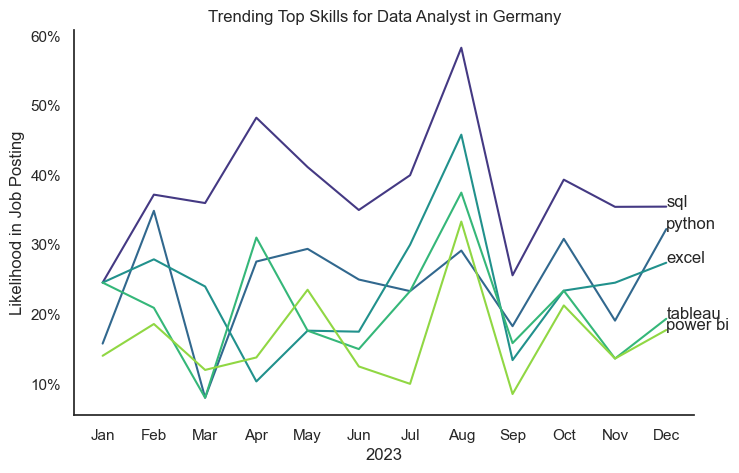

In [99]:
df_plot = df_DA_DE_per.iloc[:, :5]

sns.set_theme(style='white')
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_plot, dashes=False, palette='viridis')

sns.despine() 

plt.title('Trending Top Skills for Data Analyst in Germany')
plt.xlabel('2023')
plt.ylabel('Likelihood in Job Posting')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11, df_plot.iloc[-1, i], df_plot.columns[i])

plt.show()